<a href="https://colab.research.google.com/github/Rouliiane/2026_Intro_Python/blob/main/part-I/1.3-numpy-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.3-numpy-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [23]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"gsw": "gsw", "pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Import numpy as `np`, and encode units in your variable names.

## Exercise 1: Create and inspect

Build the following 3×4 field of temperatures (°C) as a numpy array:

`5.2 4.8 6.1 3.9 1.3 0.5 -0.8 -1.2 -2.6 -3.1 -1.9 0.2`

Print its `shape`, `ndim`, and `dtype`, and its overall mean rounded to two decimals.
Then create, and print, three arrays of the same shape without typing the shape out by hand:
all ones, a uniform reference field of 15.0 °C, and random values in [0, 1).

In [24]:
# Your solution here

import numpy as np

temperatures = np.array([
    [5.2, 4.8, 6.1, 3.9],
    [1.3, 0.5, -0.8, -1.2],
    [-2.6, -3.1, -1.9, 0.2],
])

print(temperatures)

print("shape:", temperatures.shape, "| ndim:", temperatures.ndim,temperatures.dtype, temperatures.nbytes, "bytes")


mean = temperatures.mean()
print("mean:", round(mean, 2))

print(np.full((3, 4), 15.0))
print(np.random.random(10))



[[ 5.2  4.8  6.1  3.9]
 [ 1.3  0.5 -0.8 -1.2]
 [-2.6 -3.1 -1.9  0.2]]
shape: (3, 4) | ndim: 2 float64 96 bytes
mean: 1.03
[[15. 15. 15. 15.]
 [15. 15. 15. 15.]
 [15. 15. 15. 15.]]
[0.9380085  0.60715925 0.95681863 0.38056316 0.32651677 0.90475239
 0.22587235 0.13092088 0.32612769 0.44784007]


## Exercise 2: Index and slice

Given

```python
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])
```

print the last row, the first column, and the 2×2 sub-block formed by the first two rows and the last two columns.

Finally, take a slice of the first row, change its first element to `99.0`, and print the original array. Then repeat using `.copy()`. Explain the difference in a comment.

In [25]:
# Your solution here

import numpy as np

a = np.array(
    [
        [1.0, 2.0, 3.0, 4.0],
        [5.0, 6.0, 7.0, 8.0],
        [9.0, 10.0, 11.0, 12.0],
    ]
)
print(a[0,:])
print(a[:,3])

print(a[0:2, 2:4])

# 4. Slice de la première ligne
slice_a = a[0, 0:2]

# On modifie le premier élément de la slice
slice_a[0] = 99.0

# Le tableau original est également modifié
print(a)

# 5. Même chose avec .copy()
slice_b = a[0, 0:2].copy()

# On modifie le premier élément de la copie
slice_b[0] = 99.0

# Le tableau original ne change pas
print(a)

# Une slice NumPy peut être une vue du tableau original :
# modifier la slice peut donc modifier le tableau original.
# Avec .copy(), on crée un nouveau tableau indépendant.

[1. 2. 3. 4.]
[ 4.  8. 12.]
[[3. 4.]
 [7. 8.]]
[[99.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]
[[99.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]


## Exercise 3: Masking and np.where

Given

```python
temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])
```

print the values that exceed 10 °C, their mean, and the percentage of the field they make up.
Then build a clipped field in which every value below 0 °C is set to 0, using `np.where`.

In [26]:
# Your solution here

temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])
for ligne in temp_celsius:
    for temperature in ligne:
        if temperature > 10:
            print(temperature)

mask = temp_celsius > 10
np.sum(mask)


pourcentage = (np.sum(mask) / temp_celsius.size) * 100
print(pourcentage)


print(np.where(temp_celsius < 10, 0, temp_celsius))



12.0
15.0
11.0
33.33333333333333
[[ 0. 12.  0.]
 [ 0.  0. 15.]
 [ 0.  0. 11.]]


## Exercise 4: Broadcasting and grids

Given the field below, add a per-column offset (length 4) to every row, and separately add a per-row offset (length 3) to every column.

```python
field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])
```

Then build a grid of 4 evenly spaced longitudes from 6 to 9 °E and 3 evenly spaced latitudes
from 46 to 47 °N, so that it has the same shape as `field`. On that grid, compute a synthetic temperature
field that is 15.0 °C at (6 °E, 46 °N), cools by 0.6 °C per degree of latitude northward, and warms
by 0.2 °C per degree of longitude eastward. Compute it twice, once from the 2D arrays that
`np.meshgrid` returns and once by broadcasting the 1D latitudes and longitudes directly, and
confirm with `np.allclose` that the two agree.

In [27]:
# Your solution here
field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])

print(field + col_offset)
adjusted = field + row_offset[:, None]
print(adjusted.shape)
print(adjusted)

print(field.shape)

print(col_offset.shape)

print(row_offset.shape)

print(row_offset[:, None].shape)

longitudes = np.linspace(6, 9, 4)
latitudes = np.linspace(46, 47, 3)

longitudes2d, latitudes2d = np.meshgrid(longitudes, latitudes) #mettre le 2 vecteurs enssembles
print(longitudes2d.shape)
print(latitudes2d.shape)
print(longitudes2d)
print(latitudes2d)

 #4. Slice de la première ligne
slice_longitudes = longitudes[0:2]
slice_latitudes = latitudes[0:2]

# On modifie le premier élément de la slice
slice_longitudes[0] = 15.0
slice_latitudes [0] = 15.0

# Le tableau original est également modifié
print(longitudes, latitudes)

temp_meshgrid = (
    15.0
    - 0.6 * (latitudes2d - 46)
    + 0.2 * (longitudes2d - 6)
)

print("\nTempérature avec meshgrid :")
print(temp_meshgrid)

temp_broadcast = (
    15.0
    - 0.6 * (latitudes[:, None] - 46)
    + 0.2 * (longitudes - 6)
)

print("\nTempérature avec broadcasting :")
print(temp_broadcast)

# 5. Vérifier que les deux
#    méthodes donnent le même résultat
# -----------------------------

print("\nLes deux résultats sont-ils identiques ?")
print(np.allclose(temp_meshgrid, temp_broadcast))


[[ 1.  3.  5.  7.]
 [ 5.  7.  9. 11.]
 [ 9. 11. 13. 15.]]
(3, 4)
[[11. 12. 13. 14.]
 [25. 26. 27. 28.]
 [39. 40. 41. 42.]]
(3, 4)
(4,)
(3,)
(3, 1)
(3, 4)
(3, 4)
[[6. 7. 8. 9.]
 [6. 7. 8. 9.]
 [6. 7. 8. 9.]]
[[46.  46.  46.  46. ]
 [46.5 46.5 46.5 46.5]
 [47.  47.  47.  47. ]]
[15.  7.  8.  9.] [15.  46.5 47. ]

Température avec meshgrid :
[[15.  15.2 15.4 15.6]
 [14.7 14.9 15.1 15.3]
 [14.4 14.6 14.8 15. ]]

Température avec broadcasting :
[[35.4 33.8 34.  34.2]
 [16.5 14.9 15.1 15.3]
 [16.2 14.6 14.8 15. ]]

Les deux résultats sont-ils identiques ?
False


## Exercise 5: Axis reductions

Given seasonal mean temperatures at three stations, one row per station and one column per season
(winter, spring, summer, autumn):

```python
seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])
```

print the annual mean at each station and the index of each station's warmest season. Then find the
coldest value in each season twice, once with the method and once with the numpy function, and
confirm they agree.

Finally, given four days of rainfall at two stations, one row per station,

```python
rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])
```

use `cumsum` along the right axis to get the rain to date. Print the index of the station that was
wetter after the second day and the index of the station that was wetter after all four. Are they
the same station?

In [28]:
import numpy as np

seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])

# Annual mean at each station
annual_mean = seasonal_celsius.mean(axis=1)
print("Moyenne annuelle à chaque station :", annual_mean)

# Index of each station's warmest season
hottest_season_idx = seasonal_celsius.argmax(axis=1)
print("Index de la saison la plus chaude à chaque station :", hottest_season_idx)

# Coldest value in each season (method and numpy function)
coldest_season_method = seasonal_celsius.min(axis=0)
coldest_season_np_func = np.min(seasonal_celsius, axis=0)

print("Valeur la plus froide par saison (méthode) :", coldest_season_method)
print("Valeur la plus froide par saison (fonction NumPy) :", coldest_season_np_func)

# Confirm they agree
print("Les deux méthodes pour la valeur la plus froide sont-elles identiques ?", np.allclose(coldest_season_method, coldest_season_np_func))

# Rain data
rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])

# Cumulative rain
cumulative_rain = rain_mm.cumsum(axis=1)
print("\nPluie cumulée :")
print(cumulative_rain)

# Wetter station after the second day
wetter_after_day2_idx = np.argmax(cumulative_rain[:, 1])
print("\nStation la plus humide après le deuxième jour (index) :", wetter_after_day2_idx)

# Wetter station after all four days
wetter_after_day4_idx = np.argmax(cumulative_rain[:, 3])
print("Station la plus humide après les quatre jours (index) :", wetter_after_day4_idx)

# Are they the same station?
print("Est-ce la même station ?", wetter_after_day2_idx == wetter_after_day4_idx)

Moyenne annuelle à chaque station : [10.125  7.65  12.1  ]
Index de la saison la plus chaude à chaque station : [2 2 2]
Valeur la plus froide par saison (méthode) : [-1.5  7.2 16.9  8. ]
Valeur la plus froide par saison (fonction NumPy) : [-1.5  7.2 16.9  8. ]
Les deux méthodes pour la valeur la plus froide sont-elles identiques ? True

Pluie cumulée :
[[ 0.   6.2  7.3  7.3]
 [ 2.4  2.4  2.4 10.7]]

Station la plus humide après le deuxième jour (index) : 0
Station la plus humide après les quatre jours (index) : 1
Est-ce la même station ? False


## Exercise 6: Missing data and interpolation

Given hourly air temperatures with a gap of two readings,

```python
temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])
```

fill the gap by linear interpolation against the integer index. Then print the NaN-aware mean of the
original series and the ordinary mean of the filled one. The two differ; say in a comment why.

In [29]:
# Your solution here

temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])

temp_with_gaps = temp_celsius.copy()
temp_with_gaps[2:4] = np.nan
print("nanmean (skips gaps):", np.nanmean(temp_with_gaps))
print("plain mean is contaminated:", np.mean(temp_with_gaps))  # nan
print("n missing:", np.isnan(temp_with_gaps).sum())      # np.isnan flags them; True counts as 1

x = np.arange(temp_celsius.size)

known = np.array([0, 1, 4, 5])

filled = np.interp(x, known, temp_celsius[known])

print(filled)


mean_original = np.nanmean(temp_celsius)
print(mean_original)
print(np.mean(filled))

#np.nanmean(temp_celsius) utilise uniquement les valeurs réellement mesurées.
#np.mean(filled) utilise aussi les valeurs estimées par interpolation.






nanmean (skips gaps): 15.5
plain mean is contaminated: nan
n missing: 2
[12.  13.5 15.  16.5 18.  18.5]
15.5
15.583333333333334


## Exercise 7: Avoid the dtype trap

An assistant wrote this function to compute each cell's share of the total rainfall in an integer
field of rain-gauge readings:

```python
def rain_share(rain_mm):
    share = np.zeros_like(rain_mm)
    share[:] = rain_mm / rain_mm.sum()
    return share

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])
```

Call it and print the result. Explain in a comment why every share is 0, then fix the function
twice: once keeping the preallocation but passing `dtype=float` to `np.zeros_like`, and once
without preallocating at all. Confirm that each fixed version returns a float array whose shares
sum to 1.

In [30]:
import numpy as np


# --------------------------------------------------
# 1. Fonction originale
# --------------------------------------------------

def rain_share(rain_mm):
    share = np.zeros_like(rain_mm)
    share[:] = rain_mm / rain_mm.sum()
    return share


rain_mm = np.array([[0, 2, 5],
                    [1, 0, 8],
                    [3, 4, 2]])

result = rain_share(rain_mm)

print("Original result:")
print(result)

# Toutes les valeurs sont 0 car rain_mm est un tableau d'entiers.
# np.zeros_like(rain_mm) crée donc share comme un tableau d'entiers.
# Les valeurs décimales obtenues par la division sont converties en entiers,
# donc elles deviennent 0.


# --------------------------------------------------
# 2. Correction avec préallocation
# --------------------------------------------------

def rain_share_float(rain_mm):
    share = np.zeros_like(rain_mm, dtype=float)
    share[:] = rain_mm / rain_mm.sum()
    return share


result_float = rain_share_float(rain_mm)

print("\nFixed version 1:")
print(result_float)
print("dtype:", result_float.dtype)
print("sum:", result_float.sum())


# --------------------------------------------------
# 3. Correction sans préallocation
# --------------------------------------------------

def rain_share_no_preallocation(rain_mm):
    return rain_mm / rain_mm.sum()


result_no_preallocation = rain_share_no_preallocation(rain_mm)

print(rain_share_no_preallocation(rain_mm))



Original result:
[[0 0 0]
 [0 0 0]
 [0 0 0]]

Fixed version 1:
[[0.   0.08 0.2 ]
 [0.04 0.   0.32]
 [0.12 0.16 0.08]]
dtype: float64
sum: 1.0000000000000002
[[0.   0.08 0.2 ]
 [0.04 0.   0.32]
 [0.12 0.16 0.08]]


## Exercise 8: Reshape and stack

1. Create the integers 0 to 11 as a 1D array, then reshape it into a 3×4 array and print both
   shapes.
2. Reshape the same data into a 4×3 array. Print it and say in a comment why the numbers appear
   in a different arrangement.
3. Use `reshape(-1)` to flatten your 3×4 array back to 1D, and confirm the shape.
4. Stack the 3×4 array on top of a row of zeros with `np.vstack`, and print the resulting shape.

In [31]:
import numpy as np

# 1. Create the integers 0 to 11 as a 1D array
integers_1d = np.arange(12) # Use np.arange for 0 to 11

# Reshape it into a 3x4 array and print both shapes.
array_3x4 = integers_1d.reshape(3, 4)
print("1D array:", integers_1d)
print("Shape of 1D array:", integers_1d.shape)
print("\n3x4 array:\n", array_3x4)
print("Shape of 3x4 array:", array_3x4.shape)

# 2. Reshape the same data into a 4x3 array. Print it and say in a comment why the numbers appear in a different arrangement.
array_4x3 = integers_1d.reshape(4, 3) # Reshape from the original 1D array
print("\n4x3 array:\n", array_4x3)
print("Shape of 4x3 array:", array_4x3.shape)
# Explanation for different arrangement: When reshaping, NumPy fills the new array
# row by row from the original flattened data. Since the shape changes from 3x4 to 4x3,
# the elements are arranged differently to fit the new row/column structure.

# 3. Use reshape(-1) to flatten your 3x4 array back to 1D, and confirm the shape.
flattened_array = array_3x4.reshape(-1)
print("\nFlattened array (from 3x4):\n", flattened_array)
print("Shape of flattened array:", flattened_array.shape)

# 4. Stack the 3x4 array on top of a row of zeros with np.vstack, and print the resulting shape.
row_of_zeros = np.zeros((1, 4)) # A row of 4 zeros to stack on a 3x4 array
stacked_array = np.vstack((array_3x4, row_of_zeros))
print("\nStacked array (3x4 + row of zeros):\n", stacked_array)
print("Shape of stacked array:", stacked_array.shape)


1D array: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Shape of 1D array: (12,)

3x4 array:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Shape of 3x4 array: (3, 4)

4x3 array:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
Shape of 4x3 array: (4, 3)

Flattened array (from 3x4):
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
Shape of flattened array: (12,)

Stacked array (3x4 + row of zeros):
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [ 0.  0.  0.  0.]]
Shape of stacked array: (4, 4)


## Exercise 9: Ocean float profiles

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/argo-float-cycle.png" alt="A diagram of one Argo float cycle, numbered one to seven, from deployment through drift, dive, ascent and satellite transmission" width="100%">

<em>One cycle of an Argo float: deployment, descent to a drifting depth of about 1000 m, ten days of
drift, a dive to the profiling depth, then the ascent during which the measurements are taken, and
transmission to satellite at the surface before the next cycle begins. The panel on the right shows
what one ascent produces — the temperature and salinity profiles you are about to work with.
Illustration &copy; Thomas Haessig, from
<a href="https://www.euro-argo.eu/Outreach/Educational-material/Discover-Argo-floats-for-kids/How-do-the-Argo-floats-fulfill-their-mission-in-the-Ocean">Euro-Argo ERIC's educational material</a>.</em>


[Argo](https://argo.ucsd.edu/) floats are autonomous instruments that drift with ocean currents,
periodically diving and surfacing while recording temperature, salinity, and pressure. Each dive
produces one *profile*: a set of measurements at many depth *levels*, with a single latitude,
longitude, and date attached.

This exercise uses real Argo data. Steps 1 to 8 use only what 1.1 to 1.3 cover: loading
arrays, inspecting shapes, rebuilding an axis, vectorised arithmetic, reductions along an axis,
boolean masks, and NaN-aware statistics. Steps 9 to 11 then plot what you computed.

**ℹ️ Beyond this subchapter**

Steps 9 to 11 use `matplotlib`, which gets its own treatment in 1.4. Import it once with
`import matplotlib.pyplot as plt`; after that you need only the functions below, and each is
named again where it is wanted:

- `plt.figure()` — start a new, empty figure; without it, every plot in a cell lands on the
  same axes
- [`plt.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) — a line, or
  one line per column when handed a 2D array
- [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) — a
  line with error bars
- [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) — points
- `plt.xlabel`, `plt.ylabel`, `plt.title` — each takes a string
- `plt.show()` — draw the current figure

An array of numbers with no picture attached is hard to sanity-check, which is why these three
steps sit here rather than waiting for 1.4: the profiles are the fastest way to see whether Steps 4
to 6 produced something physical.

In [32]:
# Pre-supplied: download and unzip the Argo data files.
import pooch

files = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/argo_float_data.zip",
    known_hash="sha256:dd913ba3450241bcd5d5697187ea68d398bdd7fd563a04cc74386834749c25f5",
    processor=pooch.Unzip(),
    path=pooch.os_cache("mlees"),
)
for f in sorted(files):
    print(f)

/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/P.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/S.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/T.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/date.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lat.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/levels.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lon.npy


**Step 1.** Load each `.npy` file into a numpy array with `np.load`. Name them `T` (temperature,
°C), `S` (practical salinity, unitless), `P` (pressure, dbar), `date`, `lat`, `lon`, and `level` (depth level).

Read the filenames printed above to work out which file is which.

In [33]:
import numpy as np
from pathlib import Path

# The 'files' variable from the previous cell (live-0021)
# contains the paths to the extracted .npy files.
# We can get the parent directory of these files from any of the paths.
data_dir = Path(files[0]).parent

# Load each .npy file into its respective variable
T = np.load(data_dir / "T.npy")
S = np.load(data_dir / "S.npy")
P = np.load(data_dir / "P.npy")
date = np.load(data_dir / "date.npy")
lat = np.load(data_dir / "lat.npy")
lon = np.load(data_dir / "lon.npy")
level = np.load(data_dir / "levels.npy")


**Step 2.** Print the `shape` of every array you loaded. Then answer in a comment: which
dimension do `T`, `S`, and `P` share with `level`, and which do they share with `lat`, `lon`,
and `date`?

In [34]:
# Your solution here
# Hint: the profile arrays are two-dimensional; the coordinate arrays are one-dimensional
# Hint: a 2D array's shape tells you the length of each axis — match those against the 1D shapes

print(f"Shape of T: {T.shape}")
print(f"Shape of S: {S.shape}")
print(f"Shape of P: {P.shape}")
print(f"Shape of date: {date.shape}")
print(f"Shape of lat: {lat.shape}")
print(f"Shape of lon: {lon.shape}")
print(f"Shape of level: {level.shape}")

# Answer to the questions:
# T, S, and P are 2D arrays, typically with shape (number_of_levels, number_of_profiles).
# 'level' is a 1D array, representing the different depth levels, so its shape corresponds to the first dimension of T, S, and P.
# 'lat', 'lon', and 'date' are 1D arrays, with their shape corresponding to the number of profiles, which is the second dimension of T, S, and P.

Shape of T: (78, 75)
Shape of S: (78, 75)
Shape of P: (78, 75)
Shape of date: (75,)
Shape of lat: (75,)
Shape of lon: (75,)
Shape of level: (78,)


**Step 3.** The `level` array is a regular sequence. Recreate it twice — once with `np.arange`
and once with `np.linspace` — and confirm each matches the original using `np.allclose`.

Read `level[0]`, `level[-1]`, and `level.size` first to work out the arguments.

In [35]:
# Your solution here
# Hint: np.arange(start, stop, step) excludes the stop value
# Hint: np.linspace(start, stop, num) includes both ends
# Hint: np.allclose(a, b) returns True when every pair of elements is close enough



# Re-load 'level' to ensure it has the correct content (78 elements)
data_dir = Path(files[0]).parent
level = np.load(data_dir / "levels.npy")

print(f"First 10 levels: {level[:10]}")
print(f"Last level: {level[-1]}")
print(f"Number of levels: {level.size}")

# Recreate with np.arange
# Determine step: level[1] - level[0]
step = level[1] - level[0]
# arange's stop is exclusive, so add step to level[-1]
level_arange = np.arange(level[0], level[-1] + step, step)
print(f"\nRecreated with np.arange (first 10 and last): {level_arange[:10]}...{level_arange[-1]}")
print(f"Does arange version match original? {np.allclose(level, level_arange)}")

# Recreate with np.linspace
# linspace's stop is inclusive
level_linspace = np.linspace(level[0], level[-1], level.size)
print(f"\nRecreated with np.linspace (first 10 and last): {level_linspace[:10]}...{level_linspace[-1]}")
print(f"Does linspace version match original? {np.allclose(level, level_linspace)}")


First 10 levels: [0 1 2 3 4 5 6 7 8 9]
Last level: 77
Number of levels: 78

Recreated with np.arange (first 10 and last): [0 1 2 3 4 5 6 7 8 9]...77
Does arange version match original? True

Recreated with np.linspace (first 10 and last): [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]...77.0
Does linspace version match original? True



**Step 4.** Compute the density of seawater relative to pure water, in kg m⁻³:

$$\rho - \rho_{\text{pure water}} = a\,S + b\,\Theta + c\,\Theta^{2}$$

where $S$ is salinity and $\Theta$ is the *conservative* temperature, computed from
temperature, salinity, and pressure by the `gsw` library. The constants are

```python
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3
```

The cell below imports the function. Compute `conservative_temp` and `relative_density`, print
the shape of your result, and check it matches `T`.

Both `CT_from_t` and the formula expect *absolute* salinity, in g/kg, while Argo reports
*practical* salinity, which has no unit. Absolute salinity is about 0.5 % larger; for these
profiles, using practical salinity in its place lowers every relative density by about
0.13 kg m⁻³, which is small enough to ignore here. `gsw.SA_from_SP` does the exact conversion
when it matters.

Source: Roquet et al. (2015), *J. Phys. Oceanogr.* 45, 2564–2579, and the
[TEOS-10 GSW toolbox](https://www.teos-10.org/).

In [36]:
# Pre-supplied: the conservative-temperature function from the gsw library
from gsw import CT_from_t

In [37]:
# Your solution here
# Hint: CT_from_t(SA, t, p) takes salinity, temperature, and pressure — in that order
# Hint: the whole formula is one vectorised expression; no loop is needed
# Hint: Theta**2 squares every element

a = 7.718e-1
b = -8.44e-2
c = -4.561e-3

# Compute conservative_temp using the imported CT_from_t function directly
# Use 'S' for 'SA' (salinité pratique) as per hint, and 'T' for temperature, 'P' for pressure.
conservative_temp = CT_from_t(S, T, P)

# Compute relative_density
# The formula expects conservative_temp as Theta
relative_density = a * S + b * conservative_temp + c * conservative_temp**2

print(f"Shape of conservative_temp: {conservative_temp.shape}")
print(f"Shape of relative_density: {relative_density.shape}")
print(f"Does relative_density shape match T shape? {relative_density.shape == T.shape}")

Shape of conservative_temp: (78, 75)
Shape of relative_density: (78, 75)
Does relative_density shape match T shape? True


**Step 5.** Compute the mean and the standard deviation of `T`, `S`, `P`, and
`relative_density` **at each depth**, averaging across all the profiles.

Check your result has the same shape as `level` — if it does not, you reduced along the wrong
axis.

In [38]:
# Your solution here
# Hint: pick the axis that runs across profiles, not across depths
# Hint: mean_T.shape should equal level.shape

mean_T = np.mean(T, axis=1)
print(mean_T)
print(f"Shape of mean_T: {mean_T.shape}, expected {level.shape}")
print(f"Does mean_T shape match level shape? {mean_T.shape == level.shape}")

std_T = np.std(T, axis=1)
print(f"Shape of std_T: {std_T.shape}, expected {level.shape}")
print(f"Does std_T shape match level shape? {std_T.shape == level.shape}")

mean_S = np.mean(S, axis=1)
print(f"Shape of mean_S: {mean_S.shape}, expected {level.shape}")
print(f"Does mean_S shape match level shape? {mean_S.shape == level.shape}")

std_S = np.std(S, axis=1)
print(f"Shape of std_S: {std_S.shape}, expected {level.shape}")
print(f"Does std_S shape match level shape? {std_S.shape == level.shape}")

mean_P = np.mean(P, axis=1)
print(f"Shape of mean_P: {mean_P.shape}, expected {level.shape}")
print(f"Does mean_P shape match level shape? {mean_P.shape == level.shape}")

std_P = np.std(P, axis=1)
print(f"Shape of std_P: {std_P.shape}, expected {level.shape}")
print(f"Does std_P shape match level shape? {std_P.shape == level.shape}")

[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan 10.80430666 10.49702667
 10.1749066   9.83453334  9.48625332  9.19793334  8.66010666  8.12324001
  7.60221333  7.15289333  6.74250667  6.39543999  6.04598667  5.74538665
  5.48913333  5.26604001  5.08768     4.93479998  4.77769334  4.65368
  4.54237334  4.44274664  4.35933333         nan         nan         nan
         nan         nan         nan         nan         nan         nan]
Shape of mean_T: (78,), expected (78,)
Does mean_T sh

**Step 6.** Look at the mean you just computed. Many entries are `nan`, because Argo profiles
contain missing values and an ordinary mean propagates them.

1. Count how many values in `T` are missing, using `np.isnan` and a sum over the boolean mask.
2. Express that as a percentage of all values in `T`.
3. Recompute the mean and standard deviation with `np.nanmean` and `np.nanstd`, and confirm no
   `nan` remains.

In [39]:
import numpy as np

# Your solution here
# Hint: np.isnan(T) gives a boolean array; True counts as 1 when summed
# Hint: T.size is the total number of elements
# Hint: np.isnan(result).sum() counts the nan that survived; it should be 0

# 1. Count how many values in T are missing
missing_values_T_count = np.isnan(T).sum()
print(f"Nombre de valeurs manquantes dans T: {missing_values_T_count}")

# 2. Express that as a percentage of all values in T
percentage_missing_T = (missing_values_T_count / T.size) * 100
print(f"Pourcentage de valeurs manquantes dans T: {percentage_missing_T:.2f}%")

# 3. Recompute the mean and standard deviation with np.nanmean and np.nanstd
#    and confirm no nan remains.

nanmean_T = np.nanmean(T, axis=1)
nanstd_T = np.nanstd(T, axis=1)
print(f"\nShape of nanmean_T: {nanmean_T.shape}, Has NaN: {np.isnan(nanmean_T).sum() > 0}")
print(f"Shape of nanstd_T: {nanstd_T.shape}, Has NaN: {np.isnan(nanstd_T).sum() > 0}")

nanmean_S = np.nanmean(S, axis=1)
nanstd_S = np.nanstd(S, axis=1)
print(f"Shape of nanmean_S: {nanmean_S.shape}, Has NaN: {np.isnan(nanmean_S).sum() > 0}")
print(f"Shape of nanstd_S: {nanstd_S.shape}, Has NaN: {np.isnan(nanstd_S).sum() > 0}")

nanmean_P = np.nanmean(P, axis=1)
nanstd_P = np.nanstd(P, axis=1)
print(f"Shape of nanmean_P: {nanmean_P.shape}, Has NaN: {np.isnan(nanmean_P).sum() > 0}")
print(f"Shape of nanstd_P: {nanstd_P.shape}, Has NaN: {np.isnan(nanstd_P).sum() > 0}")

nanmean_relative_density = np.nanmean(relative_density, axis=1)
nanstd_relative_density = np.nanstd(relative_density, axis=1)
print(f"Shape of nanmean_relative_density: {nanmean_relative_density.shape}, Has NaN: {np.isnan(nanmean_relative_density).sum() > 0}")
print(f"Shape of nanstd_relative_density: {nanstd_relative_density.shape}, Has NaN: {np.isnan(nanstd_relative_density).sum() > 0}")


Nombre de valeurs manquantes dans T: 101
Pourcentage de valeurs manquantes dans T: 1.73%

Shape of nanmean_T: (78,), Has NaN: False
Shape of nanstd_T: (78,), Has NaN: False
Shape of nanmean_S: (78,), Has NaN: False
Shape of nanstd_S: (78,), Has NaN: False
Shape of nanmean_P: (78,), Has NaN: False
Shape of nanstd_P: (78,), Has NaN: False
Shape of nanmean_relative_density: (78,), Has NaN: False
Shape of nanstd_relative_density: (78,), Has NaN: False


**Step 7.** Using `np.where`, build an array that labels each depth `"warm"` where the mean
temperature there is above 10 °C and `"cold"` otherwise. Print the first ten labels alongside
the first ten depths.

Then, using a boolean mask, print the depths at which the mean temperature is below 5 °C.

In [40]:
# Your solution here
# Hint: np.where(condition, value_if_true, value_if_false) works element-wise
# Hint: level[mask] selects the depths where the mask is True

# Créer un tableau qui étiquette chaque profondeur comme "warm" ou "cold"
# nanmean_T a été calculé à l'étape 6.
# level a été chargé à l'étape 1 et recréé à l'étape 3.

temperatures_labels = np.where(nanmean_T > 10, "warm", "cold")

# Afficher les dix premières étiquettes avec les dix premières profondeurs
print("Dix premières étiquettes de température et profondeurs associées:")
for i in range(10):
    print(level[i],temperatures_labels[i])

# Utiliser un masque booléen pour afficher les profondeurs où la température moyenne est inférieure à 5 °C
mask_cold_depths = nanmean_T < 5
print("\nProfondeurs où la température moyenne est inférieure à 5 °C:")
print(level[mask_cold_depths])

Dix premières étiquettes de température et profondeurs associées:
0 warm
1 warm
2 warm
3 warm
4 warm
5 warm
6 warm
7 warm
8 warm
9 warm

Profondeurs où la température moyenne est inférieure à 5 °C:
[63 64 65 66 67 68 69 70 71 72 73 74 75 76 77]


**Step 8.** Assemble a summary array with `np.vstack`: one row of depths, one of mean
temperature, one of mean salinity, and one of mean relative density — four rows in total.

Print its shape, save it to `_files/argo_summary.npy`, load it back, and confirm with `np.allclose`
that the round trip changed nothing.

In [46]:
import numpy as np
from pathlib import Path

# Votre solution ici
# Hint: np.vstack prend une liste de tableaux 1D et les empile comme des lignes
# Hint: votre résumé doit avoir la forme (4, n_levels)
# Hint: _files/ pourrait ne pas exister encore; créez-le d'abord avec Path("_files").mkdir(exist_ok=True)

# Assurez-vous d'utiliser les nanmean appropriés de l'étape 6
assembled_array = np.vstack((level, nanmean_T, nanmean_S, nanmean_relative_density))
print(f"Forme du tableau résumé assemblé: {assembled_array.shape}")

# Créer le répertoire _files si nécessaire
output_dir = Path("_files")
output_dir.mkdir(exist_ok=True)

# Sauvegarder le tableau
output_filepath = output_dir / "argo_summary.npy"
np.save(output_filepath, assembled_array)
print(f"Tableau enregistré sous: {output_filepath}")

# Charger le tableau et confirmer qu'il correspond à l'original
loaded_array = np.load(output_filepath)
print(f"Tableau chargé: {loaded_array.shape}")
print(f"Les tableaux original et chargé sont-ils identiques? {np.allclose(assembled_array, loaded_array)}")

Forme du tableau résumé assemblé: (4, 78)
Tableau enregistré sous: _files/argo_summary.npy
Tableau chargé: (4, 78)
Les tableaux original et chargé sont-ils identiques? True



**Step 9.** Plot each of `T`, `S`, `P` and `relative_density` against depth — four figures, one
per variable.

Each array is `(level, profile)`, so handing the whole array to `plt.plot` draws one line per
profile. Put the variable on the *x*-axis and `level` on the *y*-axis, which is the oceanographic
convention: depth runs down the page, and a profile is read the way the float measured it.

It will look messy, because 75 profiles are drawn on top of each other.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-profiles.png" alt="Many overlapping salinity profiles plotted against depth level, forming a dense band that shifts towards fresher water with depth" width="500">

<em>The salinity panel, as a check on yours. Label the axes and give each figure a title.</em>

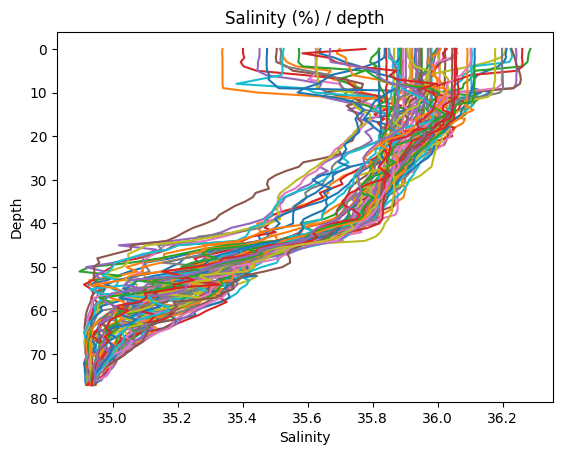

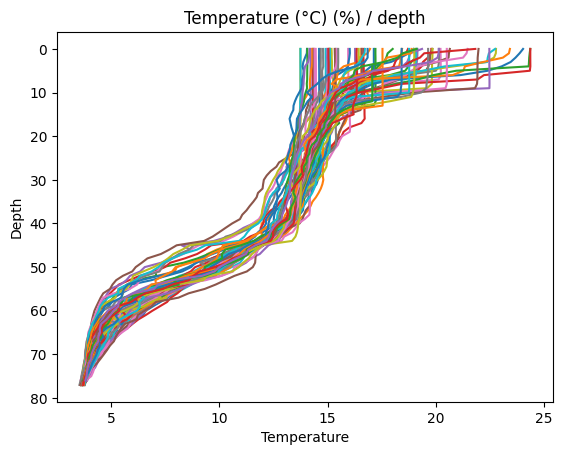

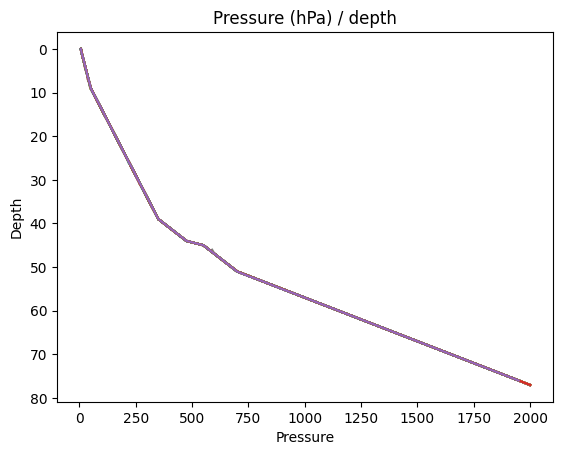

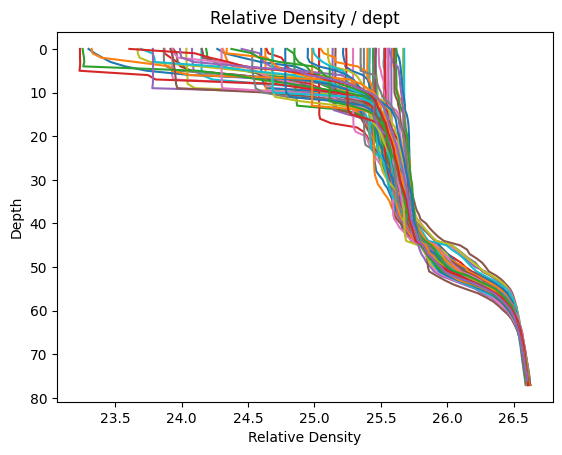

In [57]:
# Your solution here
# Hint: plt.figure() before each variable's plot, plt.show() after it
# Hint: plt.plot(S, level) draws one line per column of S
# Hint: the semicolon at the end of a plt.plot call suppresses the list of line objects
# Hint: plt.xlabel, plt.ylabel and plt.title each take a string

import matplotlib.pyplot as plt

plt.figure()

plt.plot(S, level)

plt.gca().invert_yaxis()

plt.xlabel("Salinity")
plt.ylabel("Depth")

plt.title("Salinity (%) / depth")

plt.show()

plt.figure

plt.plot(T, level)

plt.gca().invert_yaxis()

plt.xlabel("Temperature")
plt.ylabel("Depth")

plt.title("Temperature (°C) (%) / depth")


plt.show()

plt.figure

plt.plot(P, level)

plt.gca().invert_yaxis()

plt.xlabel("Pressure")
plt.ylabel("Depth")

plt.title("Pressure (hPa) / depth")



plt.show()

plt.figure

plt.plot(relative_density, level)

plt.gca().invert_yaxis()

plt.xlabel("Relative Density")
plt.ylabel("Depth")

plt.title("Relative Density / dept")
plt.show()






**Step 10.** Now plot only the *mean* profile of each variable, with the standard deviation as
error bars.

Use the NaN-aware mean and standard deviation from Step 6, and draw them with `plt.errorbar`.
Because the variable is on the *x*-axis, the spread is a *horizontal* error bar — the keyword is
`xerr`, not `yerr`.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-mean-profiles.png" alt="A single mean salinity profile against depth level with horizontal error bars at each level" width="500">

<em>The salinity panel again, reduced from 75 profiles to one line and its spread.</em>


In a comment, say what the width of the error bars tells you about how much the profiles disagree
near the surface compared with at depth.

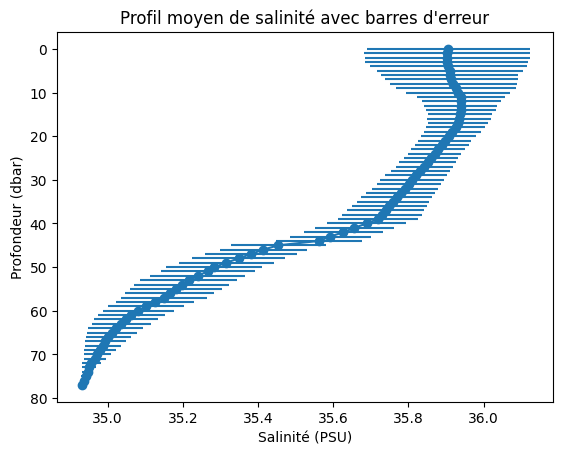

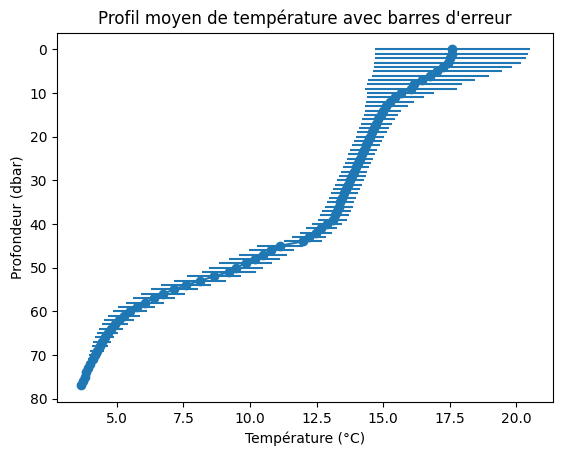

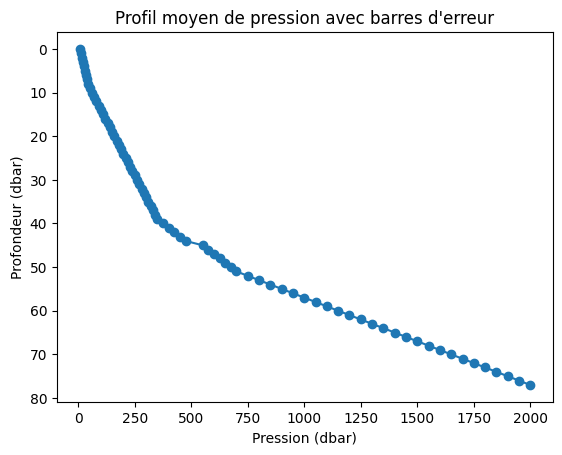

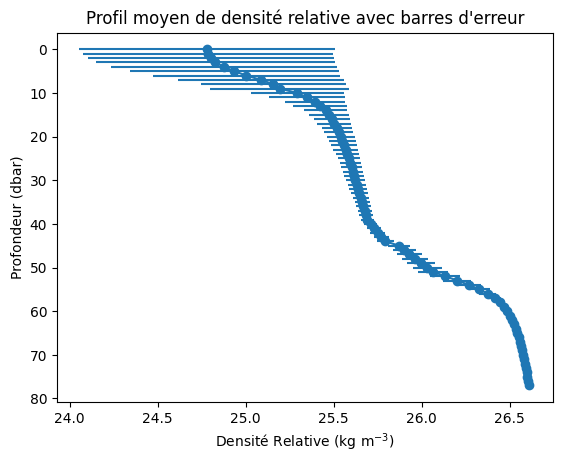

In [62]:
import matplotlib.pyplot as plt

# Profil moyen de la Salinité avec barres d'erreur
plt.figure()
plt.errorbar(nanmean_S, level, xerr=nanstd_S, fmt='-o')
plt.gca().invert_yaxis() # Inverser l'axe Y pour que la profondeur augmente vers le bas
plt.xlabel("Salinité (PSU)")
plt.ylabel("Profondeur (dbar)")
plt.title("Profil moyen de salinité avec barres d'erreur")
plt.show()

# Profil moyen de la Température avec barres d'erreur
plt.figure()
plt.errorbar(nanmean_T, level, xerr=nanstd_T, fmt='-o')
plt.gca().invert_yaxis()
plt.xlabel("Température (°C)")
plt.ylabel("Profondeur (dbar)")
plt.title("Profil moyen de température avec barres d'erreur")
plt.show()

# Profil moyen de la Pression avec barres d'erreur
plt.figure()
plt.errorbar(nanmean_P, level, xerr=nanstd_P, fmt='-o')
plt.gca().invert_yaxis()
plt.xlabel("Pression (dbar)")
plt.ylabel("Profondeur (dbar)")
plt.title("Profil moyen de pression avec barres d'erreur")
plt.show()

# Profil moyen de la Densité Relative avec barres d'erreur
plt.figure()
plt.errorbar(nanmean_relative_density, level, xerr=nanstd_relative_density, fmt='-o')
plt.gca().invert_yaxis()
plt.xlabel("Densité Relative (kg m$^{-3}$)")
plt.ylabel("Profondeur (dbar)")
plt.title("Profil moyen de densité relative avec barres d'erreur")
plt.show()

# Commentaire sur l'interprétation des barres d'erreur :
# Les barres d'erreur sont beaucoup plus larges près de la surface et se rétrécissent considérablement avec la profondeur.
# Cela indique que les profils individuels varient beaucoup plus entre eux près de la surface de l'océan
# (probablement en raison de l'influence atmosphérique, des courants de surface, etc.),
# tandis qu'en profondeur, les conditions sont beaucoup plus stables et homogènes d'un profil à l'autre.

**Step 11.** Scatter the profiles' longitudes against their latitudes.

One point per profile. Label both axes and give it a title, and set the marker size with `s=` so
the points are readable. Then print the first three entries of `date` and the last one.

In a comment, say what the dates and the shape of the cloud tell you about how this set of
profiles was collected, and by how many floats.

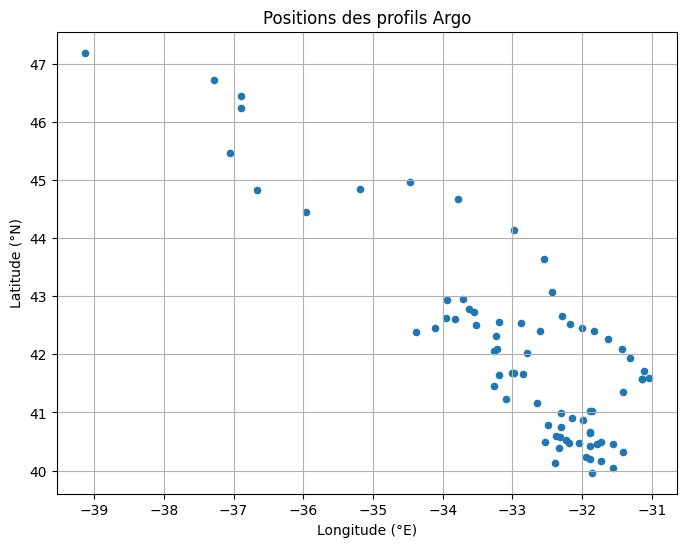

Trois premières dates de collecte: ['2012-07-13T22:33:06.019200000' '2012-07-23T22:54:59.990400000'
 '2012-08-02T22:55:52.003200000']
Dernière date de collecte: 2014-07-24T03:02:33.014400000


In [70]:
# Your solution here
# Hint: plt.scatter(lon, lat)
# Hint: lon and lat have one entry per profile, not per level
# Hint: look at the spacing between consecutive dates

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(lon, lat, s=20)
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Positions des profils Argo")
plt.grid(True)
plt.show()

print("Trois premières dates de collecte:", date[:3])
print("Dernière date de collecte:", date[-1])

# Commentaire sur l'interprétation des dates et de la forme du nuage de points :
# Les dates montrent des intervalles d'environ 10 jours entre les profils consécutifs,
# ce qui est typique du cycle de fonctionnement d'une bouée Argo (environ 10 jours de dérive).
# Le nuage de points représente la trajectoire d'une seule bouée (ou d'un très petit nombre de bouées)
# sur une période donnée, car les points sont connectés et ne sont pas dispersés sur une vaste zone.
# On observe un déplacement général vers le sud-est au fil du temps (en regardant l'ordre des dates
# et la position géographique), ce qui indique la dérive de la bouée avec les courants océaniques.

**ℹ️ What you just did**

You loaded a real oceanographic dataset, worked out its structure from the array shapes alone,
rebuilt a coordinate axis and verified it, evaluated a published equation of state as one
vectorised expression over 5,850 measurements (78 depth levels by 75 profiles), reduced along the
right axis, counted the missing values and switched to NaN-aware statistics, and saved a derived
product.

None of the computation needed a loop over the data. In the next subchapter `xarray` attaches the
names (depth, profile, latitude) to the axes you have been tracking by hand, and `matplotlib` gets
its full treatment, including the line, error-bar and scatter plots you drew here.